# 🍷 Red Wine Quality — EDA & Decision Tree Classification

**Objective:** Explore the red wine quality dataset, clean the data, analyze relationships between variables, build a Decision Tree classifier, evaluate it, tune its hyperparameters, and predict the quality of a new wine sample.

### Notebook Workflow
1. Load and inspect the dataset
2. Clean duplicate records
3. Perform univariate, bivariate, and multivariate analysis
4. Build and evaluate a Decision Tree classifier
5. Analyze ROC/AUC performance
6. Tune hyperparameters with GridSearchCV
7. Validate with cross-validation and a learning curve
8. Predict quality for a new wine sample


# 1. Import Libraries

Import the libraries required for data handling, visualization, analysis, and machine learning.

In [ ]:
# Import libraries used throughout the notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

Load the red wine quality dataset into a pandas DataFrame.

In [ ]:
# Load the red wine quality dataset.
df=pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Preview the Last Rows

Check the final records to confirm the dataset loaded correctly.

In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


### Check Dataset Dimensions

Find the number of rows and columns in the dataset.

In [ ]:
print(df.shape)

(1599, 12)


### Inspect Column Names

Display the feature and target column names.

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

### Inspect Data Types and Structure

Review column data types, non-null counts, and DataFrame structure.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### Descriptive Statistics

Generate summary statistics for the numerical variables.

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Check for Missing Values

Identify columns containing null or missing values.

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Check for Duplicate Records

Count duplicate rows before cleaning.

In [ ]:
df.duplicated().sum()

np.int64(240)

### Remove Duplicate Records

Remove duplicate observations so repeated rows do not influence the analysis.

In [ ]:
# Remove duplicate observations.
df=df.drop_duplicates()

### Verify Data Cleaning

Confirm the dataset dimensions and duplicate count after cleaning.

In [ ]:
# Verify that duplicate removal was successful.
print("Dataset shape after duplicate removal:", df.shape)
print("Duplicate rows after removal:", df.duplicated().sum())

Dataset shape after duplicate removal: (1359, 12)
Duplicate rows after removal: 0


In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

### Inspect Wine Quality Distribution

Examine how the target variable `quality` is distributed.


Wine quality distribution:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


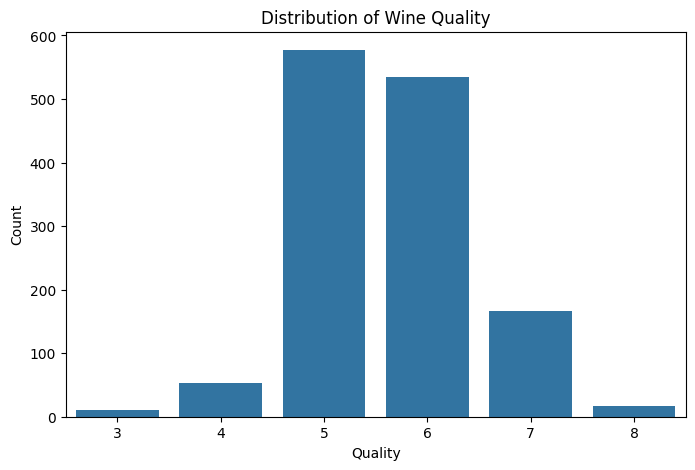

In [ ]:
print("\nWine quality distribution:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

# 3. Univariate Analysis

Analyze individual variables to understand distributions and potential unusual values.

# Univariate Analysis

### Histograms and KDE Plots

Visualize the distribution of each numerical variable.

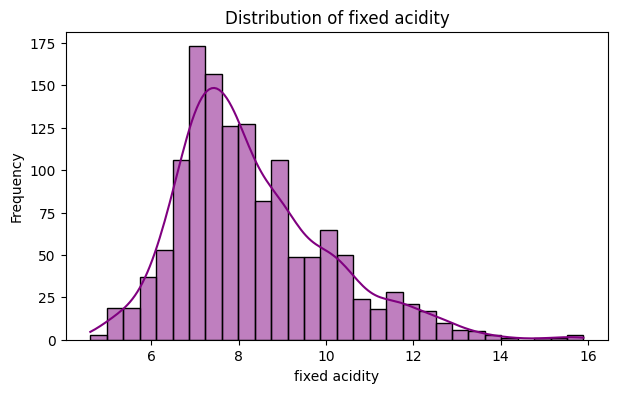

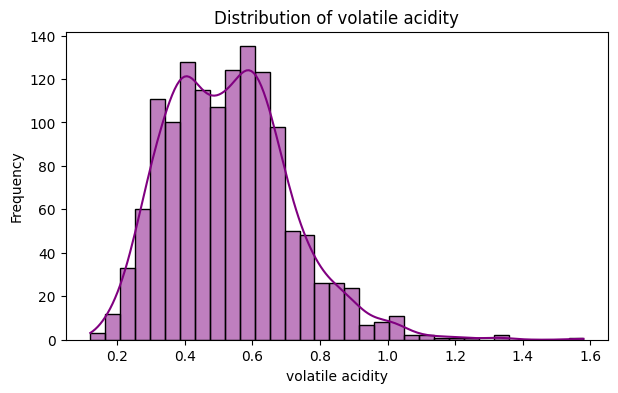

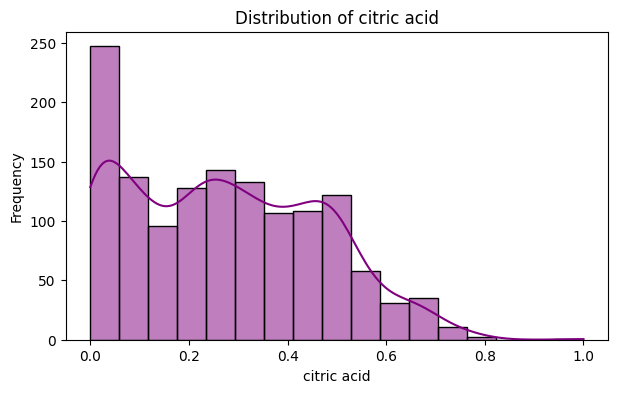

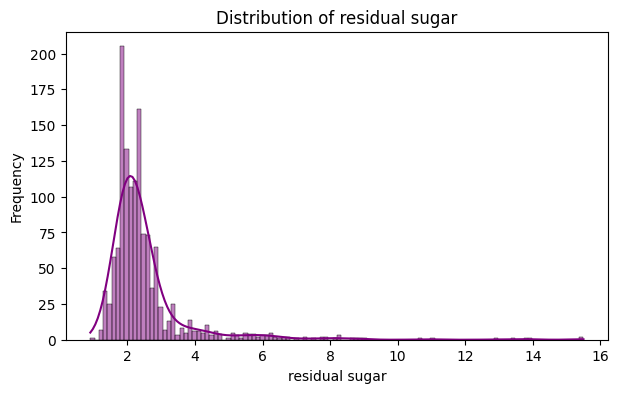

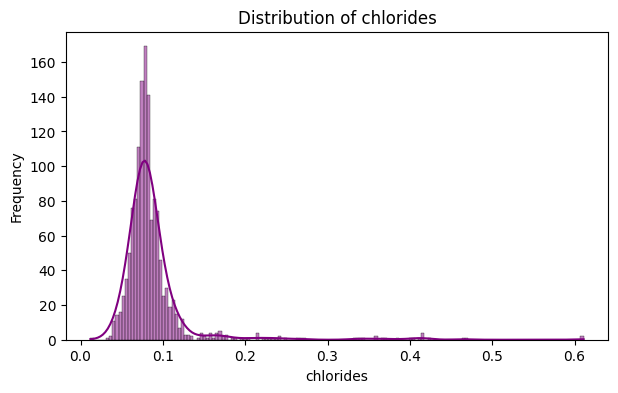

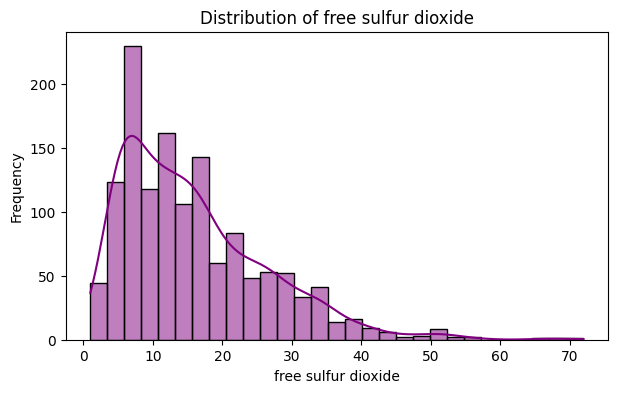

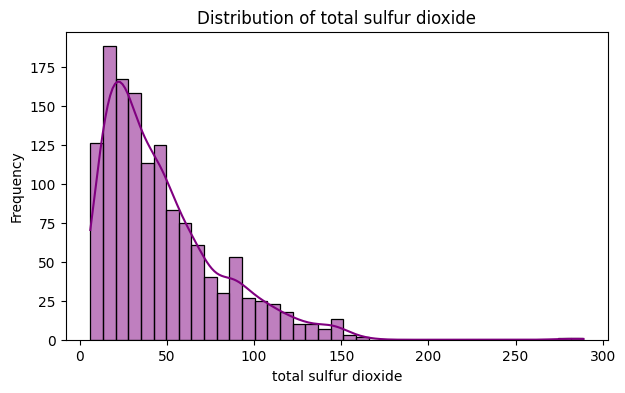

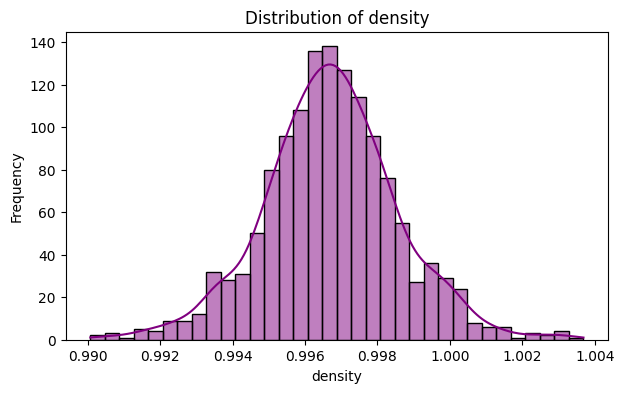

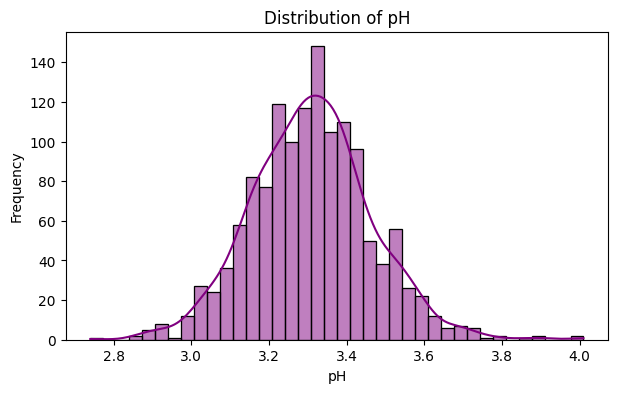

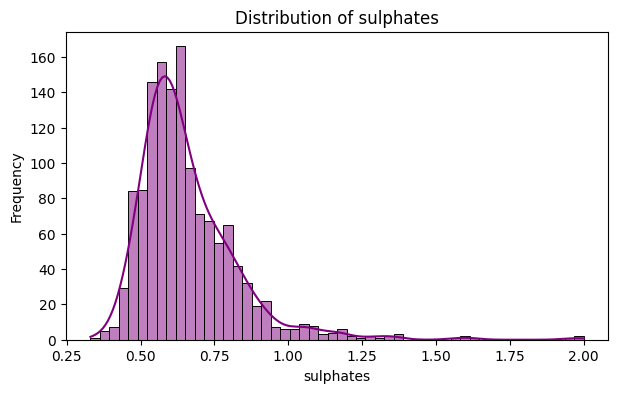

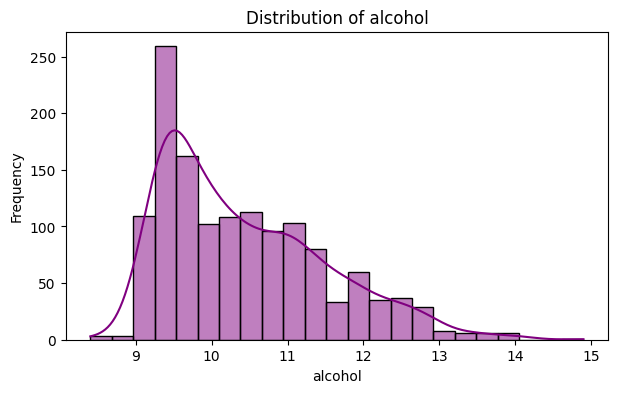

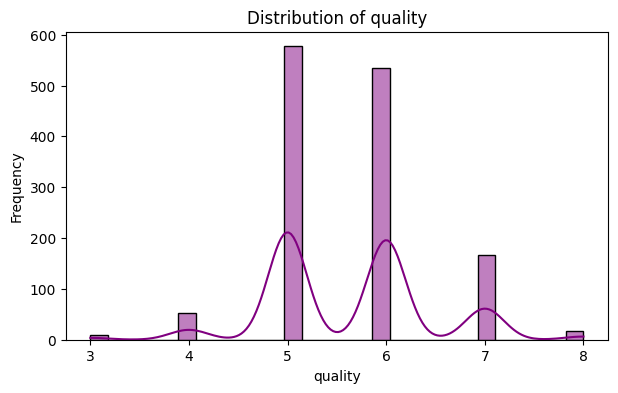

In [ ]:
# Plot the distribution of each numerical feature.
#Histogram + KDE
numeric_cols=df.columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True,color='purple')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Boxplots for Numerical Variables

Inspect spread, central tendency, and potential outliers.

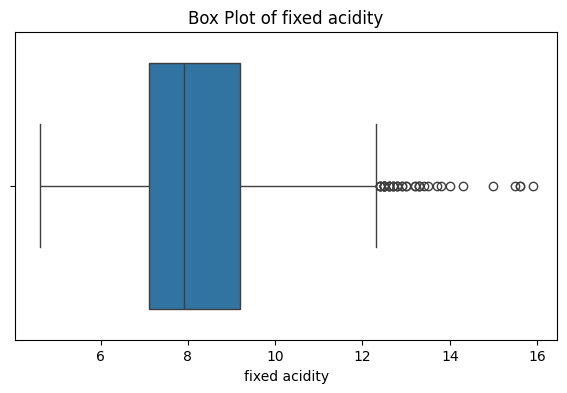

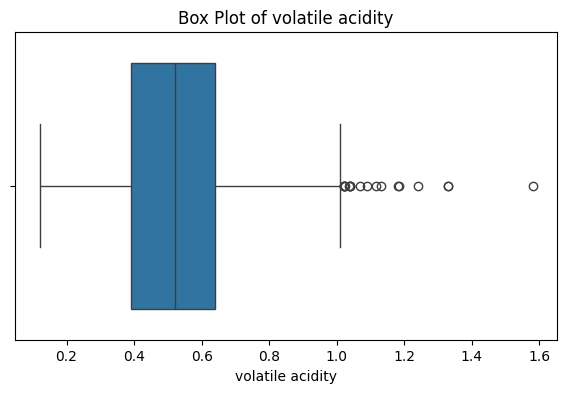

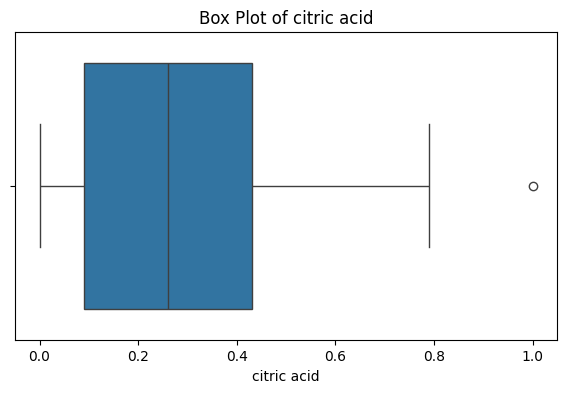

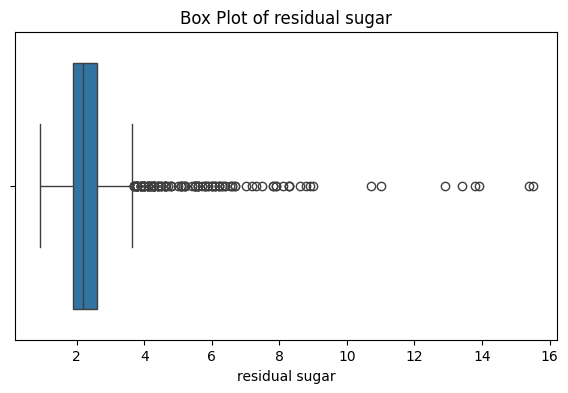

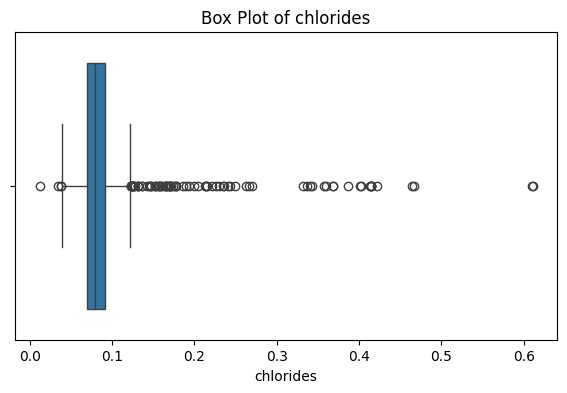

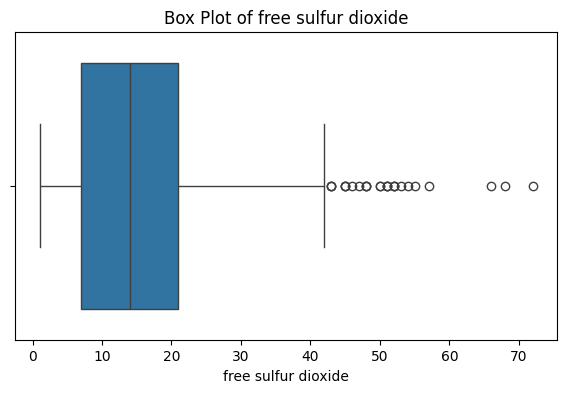

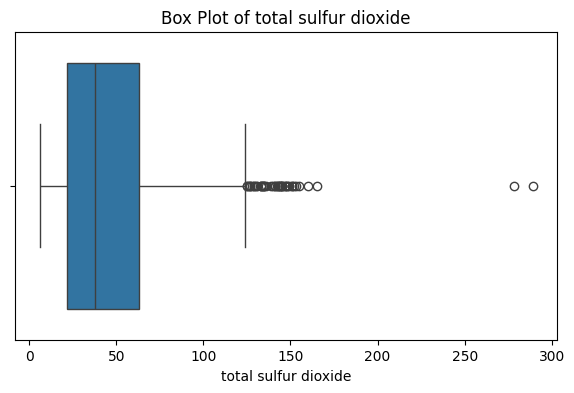

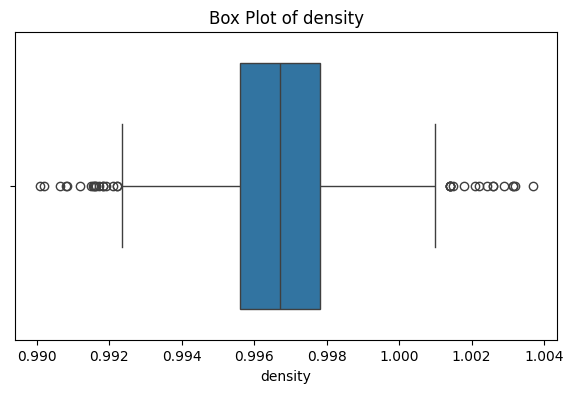

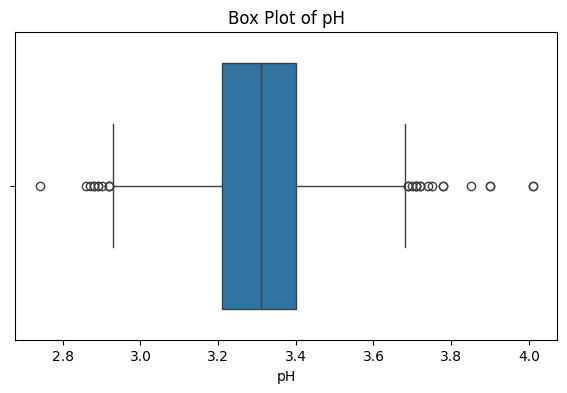

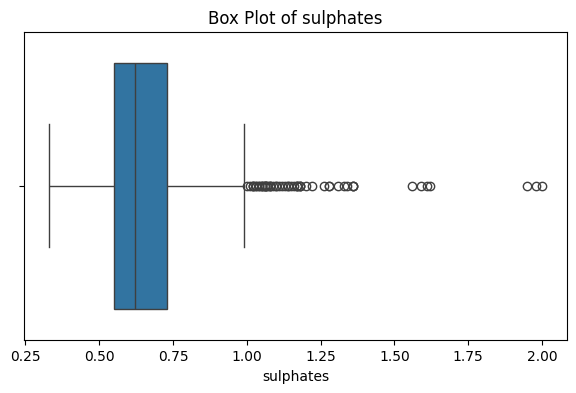

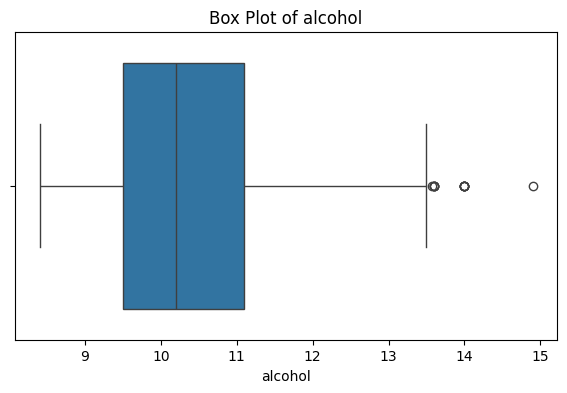

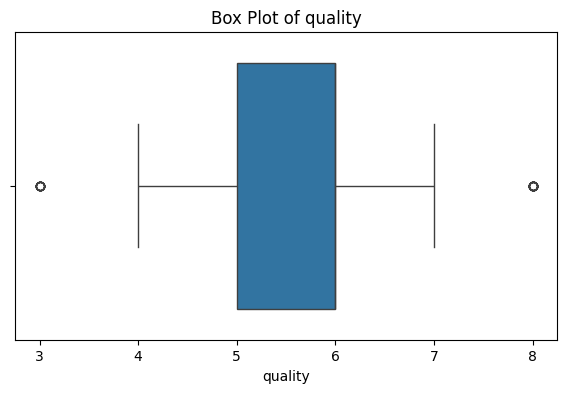

In [ ]:
# Use boxplots to inspect spread and potential outliers.
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

### Detect Outliers Using the IQR Method

Identify observations outside the 1.5 × IQR range.

### Count Outliers by Feature

Calculate the number of detected outliers for every feature.

In [ ]:
# Count detected outliers for each feature.
#Detect outliers for every feature
features =  df.drop(columns=['quality'])

#Calculate Q1 and Q3
Q1=features.quantile(0.25)
Q3=features.quantile(0.75)

#Calculate IQR
IQR=Q3-Q1

#Calculate lower and upper limits
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

#Detect outliers
outlier_mask=(features < lower_bound) | (features > upper_bound)

#Count outliers for each feature
outlier_counts=outlier_mask.sum()

#Display the outlier counts for each feature
print("Outlier Counts for Each Feature:")
print(outlier_counts)

#Percentage of outliers
outlier_percentage=(outlier_counts/len(features))*100

#Display the percentage of outliers for each feature
print("\nPercentage of Outliers for Each Feature:")
print(outlier_percentage)

#Create summary table
outlier_summary=pd.DataFrame({
    'Q1':Q1,
    'Q3':Q3,
    'IQR':IQR,
    'Lower Bound':lower_bound,
    'Upper Bound':upper_bound,
    'Outlier Count':outlier_counts,
    'Outlier Percentage':outlier_percentage
})

#Display
print("\nOutlier Summary:")
print(outlier_summary.round(3))

Outlier Counts for Each Feature:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
dtype: int64

Percentage of Outliers for Each Feature:
fixed acidity           3.016924
volatile acidity        1.398087
citric acid             0.073584
residual sugar          9.271523
chlorides               6.401766
free sulfur dioxide     1.913171
total sulfur dioxide    3.311258
density                 2.575423
pH                      2.060338
sulphates               4.047093
alcohol                 0.883002
dtype: float64

Outlier Summary:
                          Q1      Q3     IQR  Lower Bound  Upper Bound  \
fixed acidity          7.100   9.200   2.100        3.950       12.350   
volatile acidity       0.390   0.640   0.250        0.015   

### Visualize Outlier Counts

Compare outlier counts across features.

In [ ]:
# Plot outlier counts for quick comparison.
# Number of outliers in each feature
print("Outliers in each feature:\n")

for column in features.columns:
    print(f"{column:25s} : {outlier_counts[column]}")

Outliers in each feature:

fixed acidity             : 41
volatile acidity          : 19
citric acid               : 1
residual sugar            : 126
chlorides                 : 87
free sulfur dioxide       : 26
total sulfur dioxide      : 45
density                   : 35
pH                        : 28
sulphates                 : 55
alcohol                   : 12


### Wine Quality Distribution Plot

Visualize the frequency of each wine quality score.

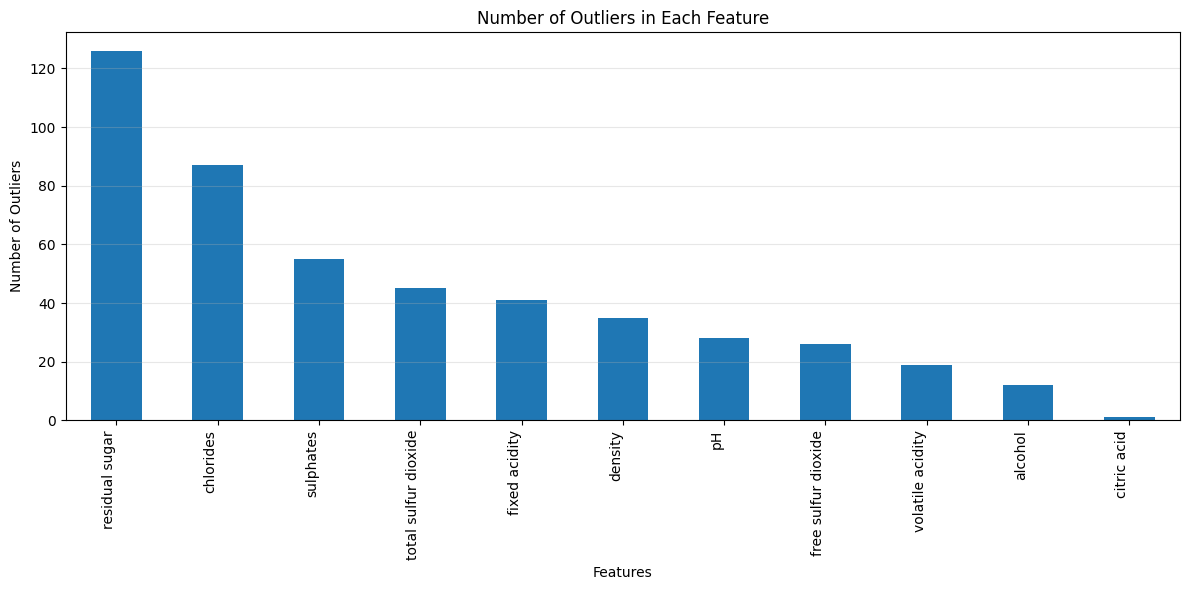

In [ ]:
# Plot the frequency of each wine quality score.
plt.figure(figsize=(12,6))
outlier_counts.sort_values(ascending=False).plot(kind='bar')
plt.title('Number of Outliers in Each Feature')
plt.xlabel('Features')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=90,ha='right')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

### Quality Value Counts

Display the exact number of observations for each quality score.

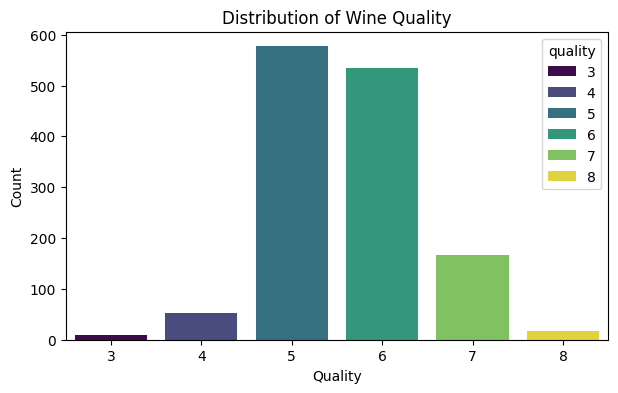

In [ ]:
#Quality Distribution
plt.figure(figsize=(7,4))

sns.countplot(
    x="quality",
    data=df,
    hue="quality",
    palette="viridis",
    legend=True
)

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

# 4. Bivariate Analysis

Study relationships between pairs of variables, especially features versus wine quality.

In [ ]:
df['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


### Alcohol vs. Wine Quality

Compare alcohol levels across different quality scores.

# Bivariate Analysis

### Select Features for Relationship Analysis

Prepare selected numerical features for further bivariate analysis.

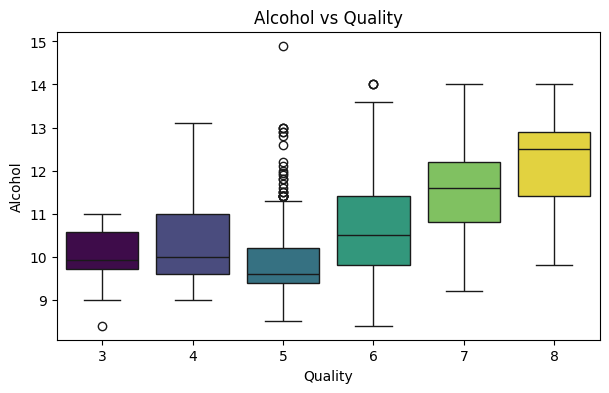

In [ ]:
# Alcohol vs Quality
plt.figure(figsize=(7,4))

sns.boxplot(
    x="quality",
    y="alcohol",
    data=df,
    hue="quality",
    palette="viridis",
    legend=False
)

plt.title("Alcohol vs Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

### Alcohol vs. Quality Scatter Plot

Visualize the relationship between alcohol content and wine quality.

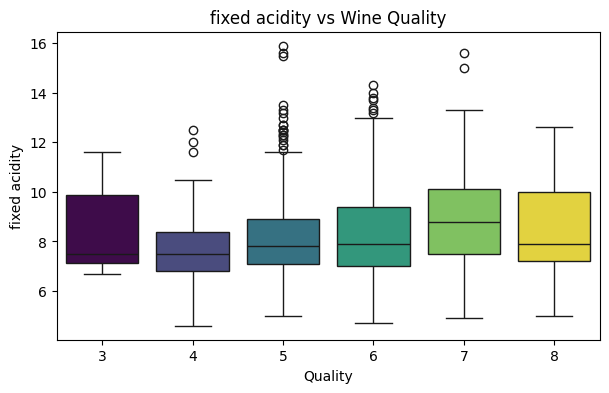

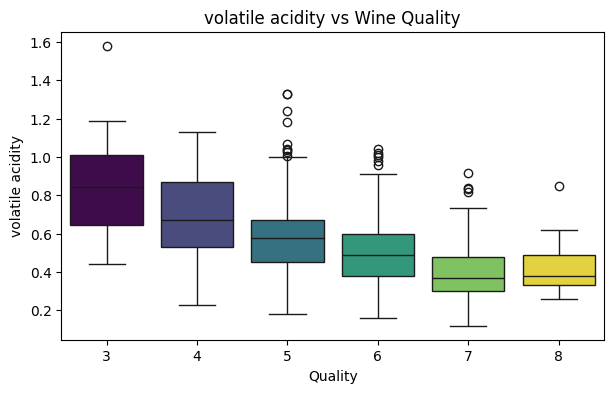

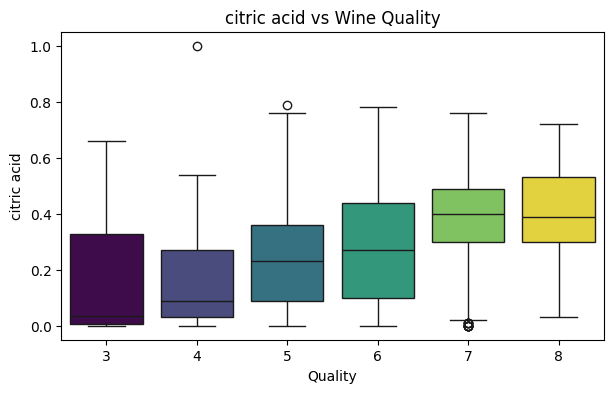

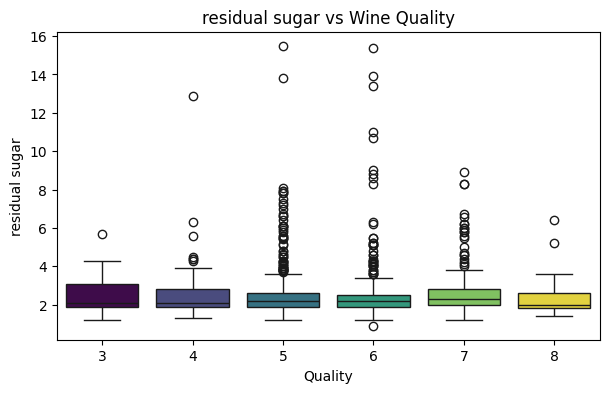

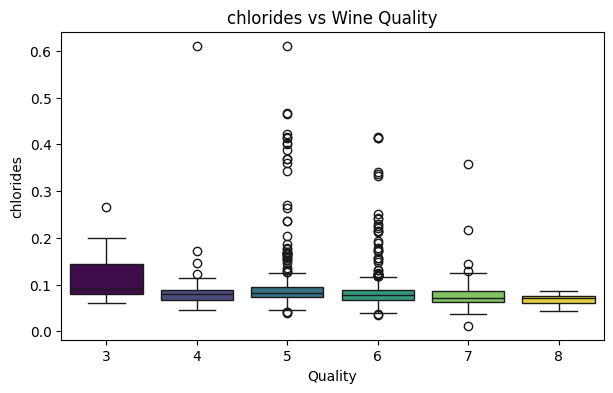

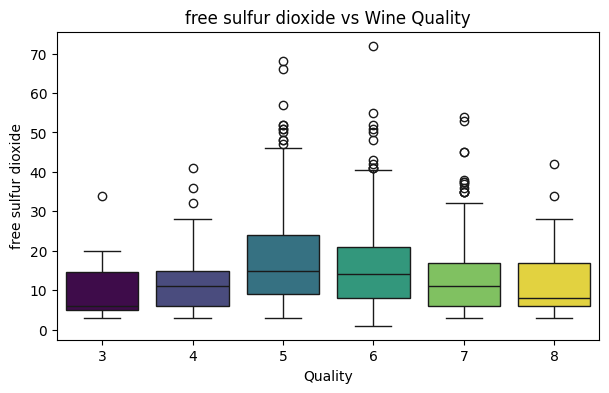

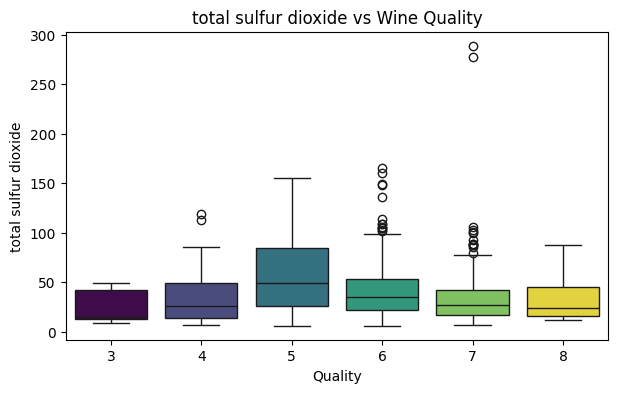

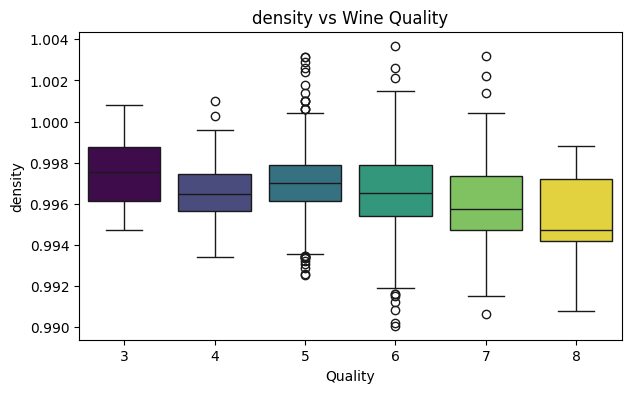

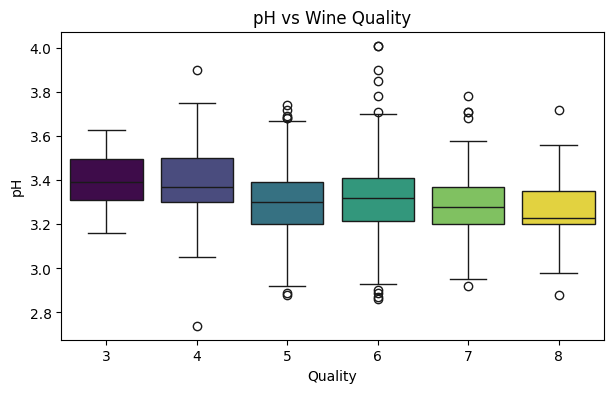

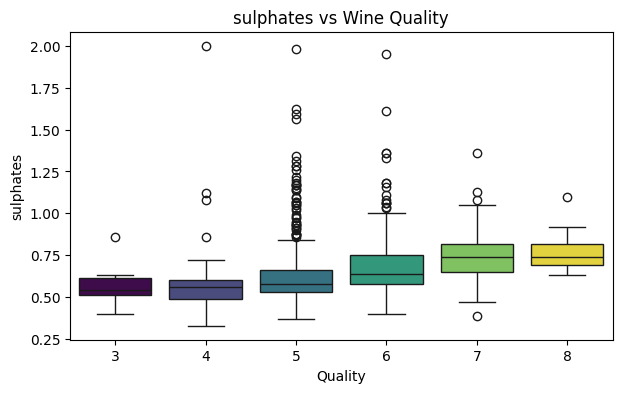

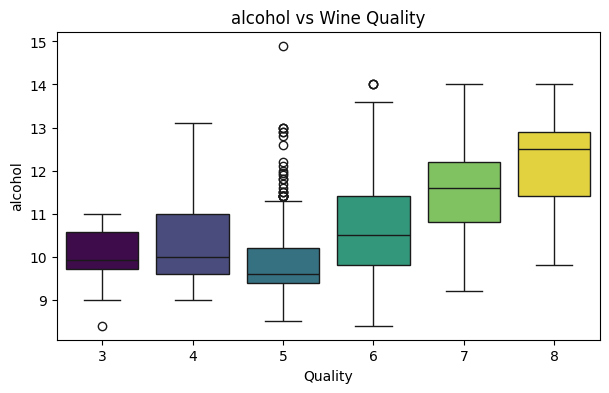

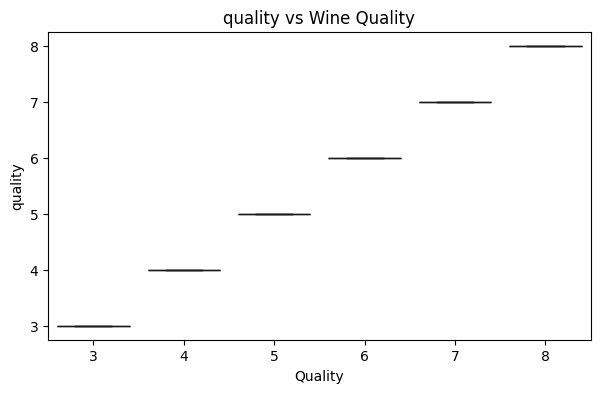

In [ ]:
# Visualize alcohol content against wine quality.
features=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']

for col in features:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        x="quality",
        y=col,
        data=df,
        hue="quality",
        palette="viridis",
        legend=False
    )
    plt.title(f"{col} vs Wine Quality")
    plt.xlabel("Quality")
    plt.ylabel(col)
    plt.show()

### Volatile Acidity vs. Quality

Visualize how volatile acidity varies with wine quality.

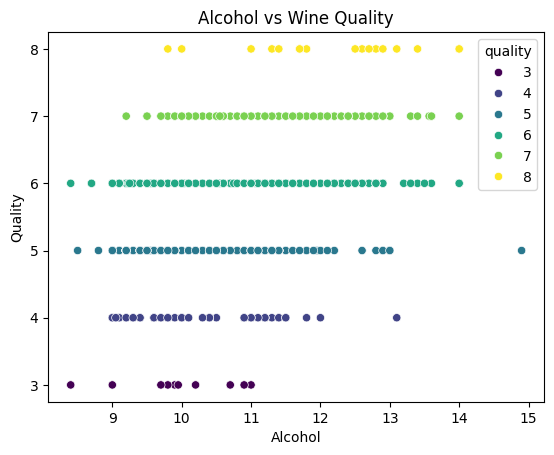

In [ ]:
# Visualize volatile acidity against wine quality.
#Scatter Plot
sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality",
    hue="quality",
    palette="viridis"
)

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

# 5. Multivariate Analysis

Examine relationships among multiple variables simultaneously.

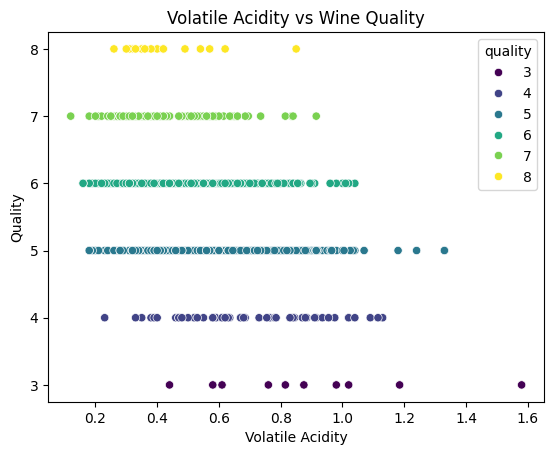

In [ ]:
# Calculate and visualize correlations among numerical variables.
sns.scatterplot(
    data=df,
    x="volatile acidity",
    y="quality",
    hue="quality",
    palette="viridis"
)

plt.title("Volatile Acidity vs Wine Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.show()

### Pair Plot of Selected Features

Visualize pairwise relationships among selected features and the target.

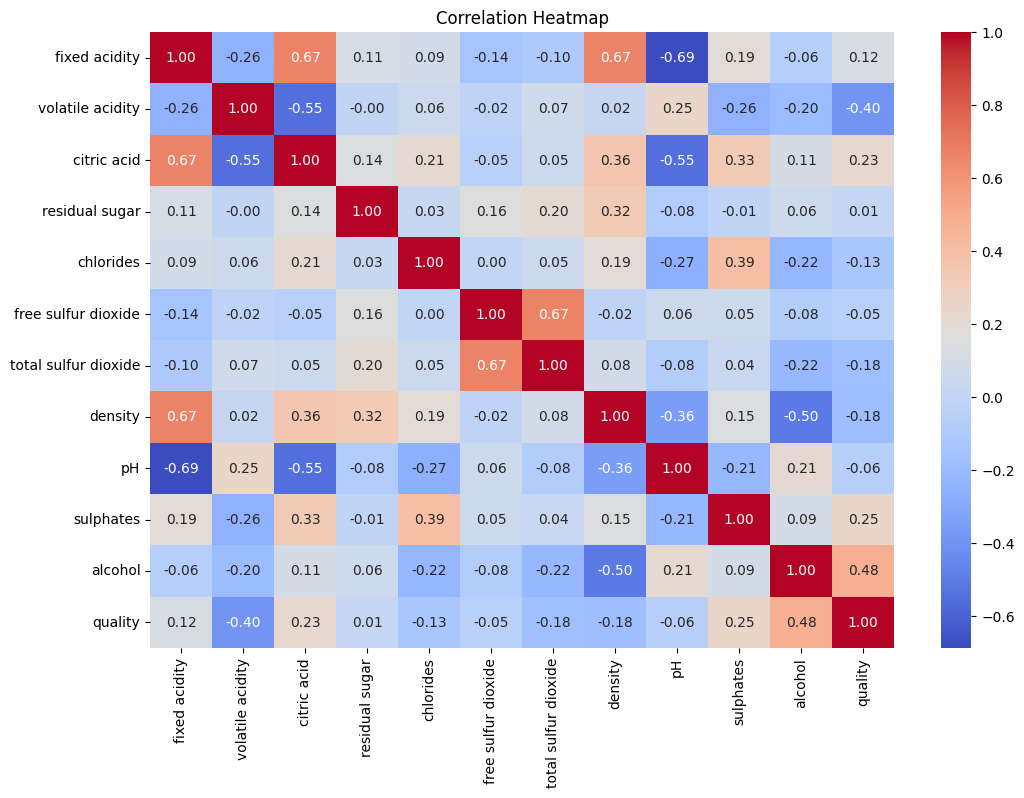

In [ ]:
# Examine pairwise relationships among selected features.
# Multivariate Analysis

plt.figure(figsize=(12,8))

corr=df.corr()

sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### Create Quality Groups

Group quality scores into Low, Medium, and High categories for comparison.

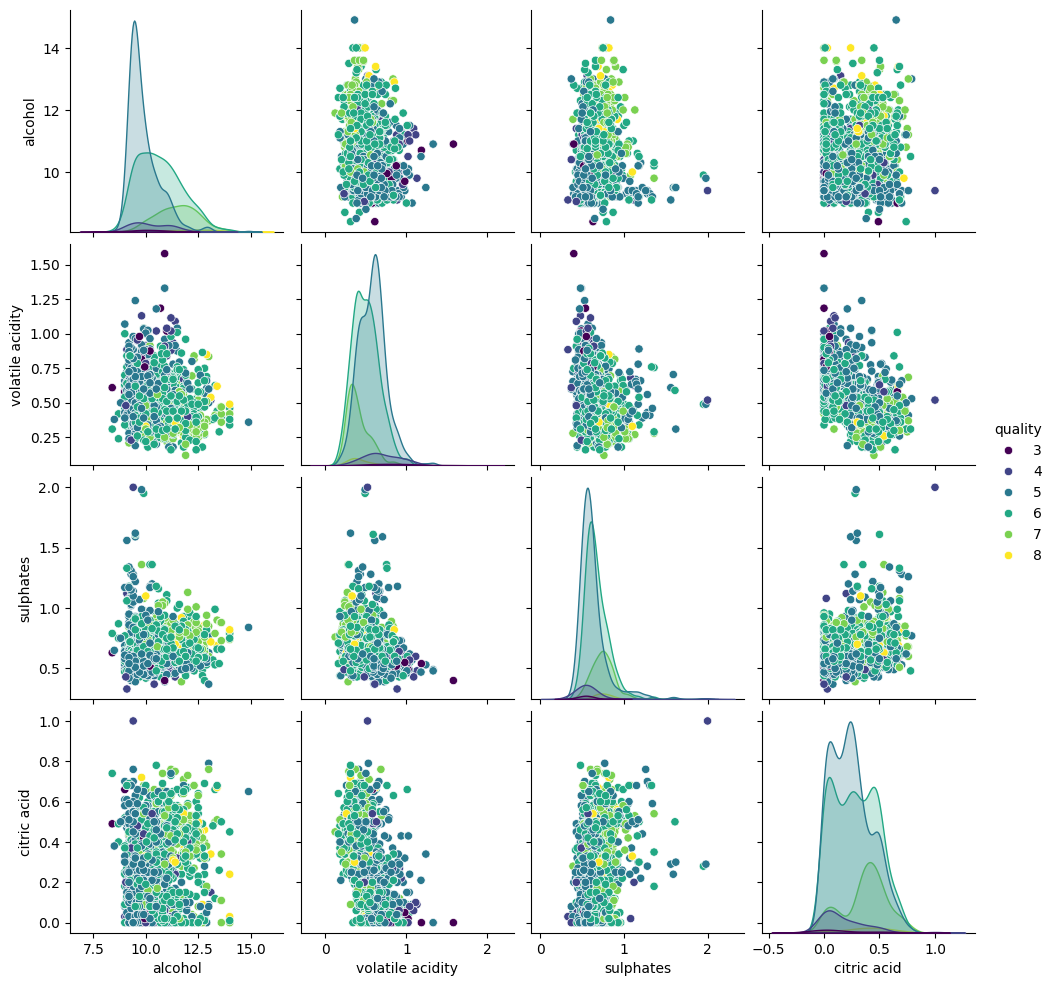

In [ ]:
# Convert numeric quality scores into broader quality groups.
#Pair Plot
selected=['alcohol','volatile acidity','sulphates','citric acid','quality']

sns.pairplot(df[selected],hue='quality',palette='viridis')
plt.show()

### Compare Alcohol Across Quality Groups

Examine alcohol levels across the broader quality categories.

In [ ]:
# Compare alcohol content across quality groups.
#Multivariate Analysis using Quality Groups
df['quality_group']=pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels=['Low','Medium','High']
)

# 6. Decision Tree Classification

Prepare the data and build a Decision Tree classifier.

/tmp/ipykernel_1517/3923837576.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


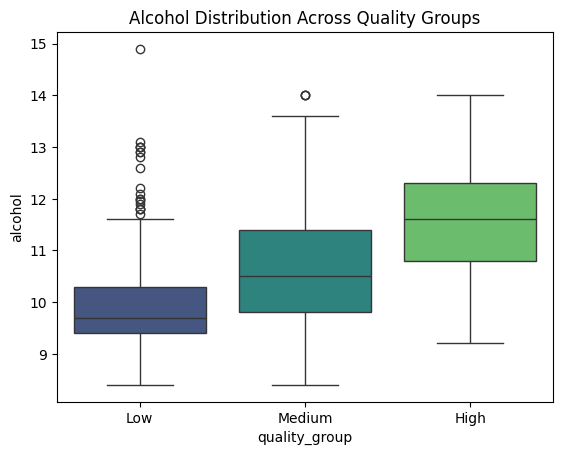

In [ ]:
sns.boxplot(
    data=df,
    x='quality_group',
    y='alcohol',
    palette='viridis'
)

plt.title('Alcohol Distribution Across Quality Groups')
plt.show()

### Define Features and Target

Separate predictor variables (`X`) from the target variable (`y`).

In [ ]:
# X contains predictor variables; y contains the target quality score.
from sklearn .model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)


### Check Feature and Target Shapes

Verify the dimensions of the feature matrix and target vector.

In [ ]:
x=df.drop('quality',axis=1)
y=df['quality']

### Inspect Target Class Distribution

Check the number of samples in each quality class.

In [ ]:
print("x shape",x.shape)
print("y shape",y.shape)

x shape (1359, 12)
y shape (1359,)


### Split Data into Training and Testing Sets

Create stratified training and testing sets while preserving class proportions.

In [ ]:
# Split the data into training and testing subsets using stratification.
print(y.value_counts().sort_index())

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


### Select Decision Tree Criterion

Use entropy as the splitting criterion.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### Initialize the Decision Tree Model

Create the initial Decision Tree classifier.

In [ ]:
# Create the initial Decision Tree classifier.
criterion='entropy'

### Create Quality Groups for Analysis

Create categorical quality groups; these are excluded from the model inputs later.

In [ ]:
dt_model=DecisionTreeClassifier(criterion=criterion,random_state=42)

### Inspect Feature Names

Review the columns being used as model inputs.

In [ ]:
df['quality_group']=pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels=['Low','Medium','High']
)

### Check for Non-Numeric Features

Confirm whether any non-numeric columns remain.

In [ ]:
print(x.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality_group'],
      dtype='object')


### Define the Target Variable

Set wine quality as the classification target.

In [ ]:
print(x.select_dtypes(exclude=['number']).columns)

Index(['quality_group'], dtype='object')


### Finalize Model Features

Remove the target and analysis-only grouping column from the feature matrix.

In [ ]:
y=df['quality']


### Verify Feature Names and Data Types

Confirm that the final model inputs are numeric.

In [ ]:
x=df.drop(columns=['quality','quality_group'],errors='ignore')

### Create the Final Train/Test Split

Split the finalized data using stratification.

In [ ]:
# Split the finalized data into training and testing subsets.
print(x.columns)
print(x.dtypes)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


### Verify Split Dimensions

Check the shapes of the training and testing datasets.

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### Initialize the Final Decision Tree

Create the Decision Tree classifier used for training.

In [ ]:
# Create the final Decision Tree classifier.
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (1087, 11)
x_test shape: (272, 11)
y_train shape: (1087,)
y_test shape: (272,)


### Train the Decision Tree

Fit the model using the training data.

In [ ]:
# Train the model on the training data.
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(criterion=criterion,random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Generate Predictions

Predict wine quality for both training and test sets.

In [ ]:
# Generate predictions for training and test data.
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Training Accuracy

Measure performance on the training set.

In [ ]:
# Evaluate performance on the training set.
y_train_pred=dt_model.predict(x_train)
y_test_pred=dt_model.predict(x_test)

### Test Accuracy

Measure performance on unseen test data.

In [ ]:
# Evaluate generalization performance on the unseen test set.
train_accuracy=accuracy_score(y_train,y_train_pred)
print("Train Accuracy:",train_accuracy)

Train Accuracy: 1.0


### Precision, Recall, and F1-Score

Calculate weighted classification metrics on the test set.

In [ ]:
# Calculate weighted classification metrics.
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Test Accuracy:",test_accuracy)

Test Accuracy: 0.4963235294117647


### Classification Report

Display precision, recall, F1-score, and support for each class.

In [ ]:
# Print a complete classification report.
print("Precision:",
      precision_score(y_test,y_test_pred,average='weighted'))

print("Recall:",
      recall_score(y_test,y_test_pred,average='weighted'))

print("F1 Score:",
      f1_score(y_test,y_test_pred,average='weighted'))

Precision: 0.49434982217769985
Recall: 0.4963235294117647
F1 Score: 0.4951045941835992


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Visualize the Decision Tree

Render the learned tree to inspect its structure.

In [ ]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.64      0.62      0.63       116
           6       0.47      0.50      0.48       107
           7       0.29      0.30      0.30        33
           8       0.00      0.00      0.00         3

    accuracy                           0.50       272
   macro avg       0.23      0.24      0.24       272
weighted avg       0.49      0.50      0.50       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion Matrix

Visualize correct and incorrect predictions for each quality class.

In [ ]:
# Build and visualize the confusion matrix.
plt.figure(figsize=(24,12))
plot_tree

<function sklearn.tree._export.plot_tree(decision_tree, *, max_depth=None, feature_names=None, class_names=None, label='all', filled=False, impurity=True, node_ids=False, proportion=False, rounded=False, precision=3, ax=None, fontsize=None)>

<Figure size 2400x1200 with 0 Axes>

### Inspect Tree Complexity

Report the tree depth and number of leaf nodes.

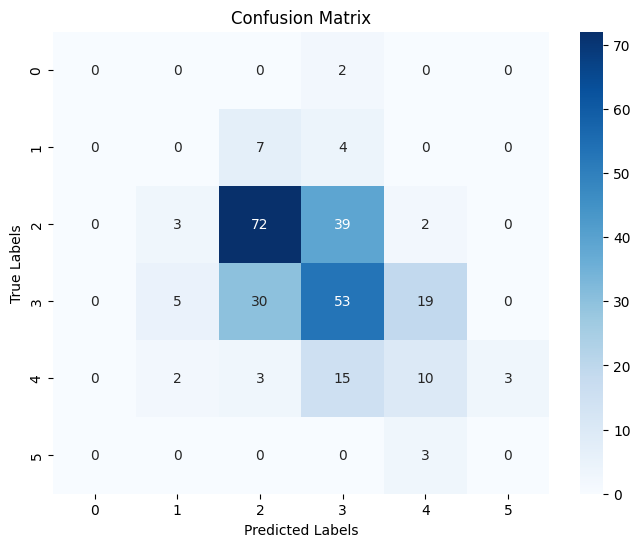

In [ ]:
# Inspect model complexity using depth and leaf count.
#Confusion Matrix
cm=confusion_matrix(y_test,y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### Detailed Decision Tree Visualization

Display the tree with feature names and class labels.

In [ ]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaf Nodes:", dt_model.get_n_leaves())

Tree Depth: 18
Number of Leaf Nodes: 299


### Alternate Decision Tree Visualization

Render the trained tree using `plot_tree`.

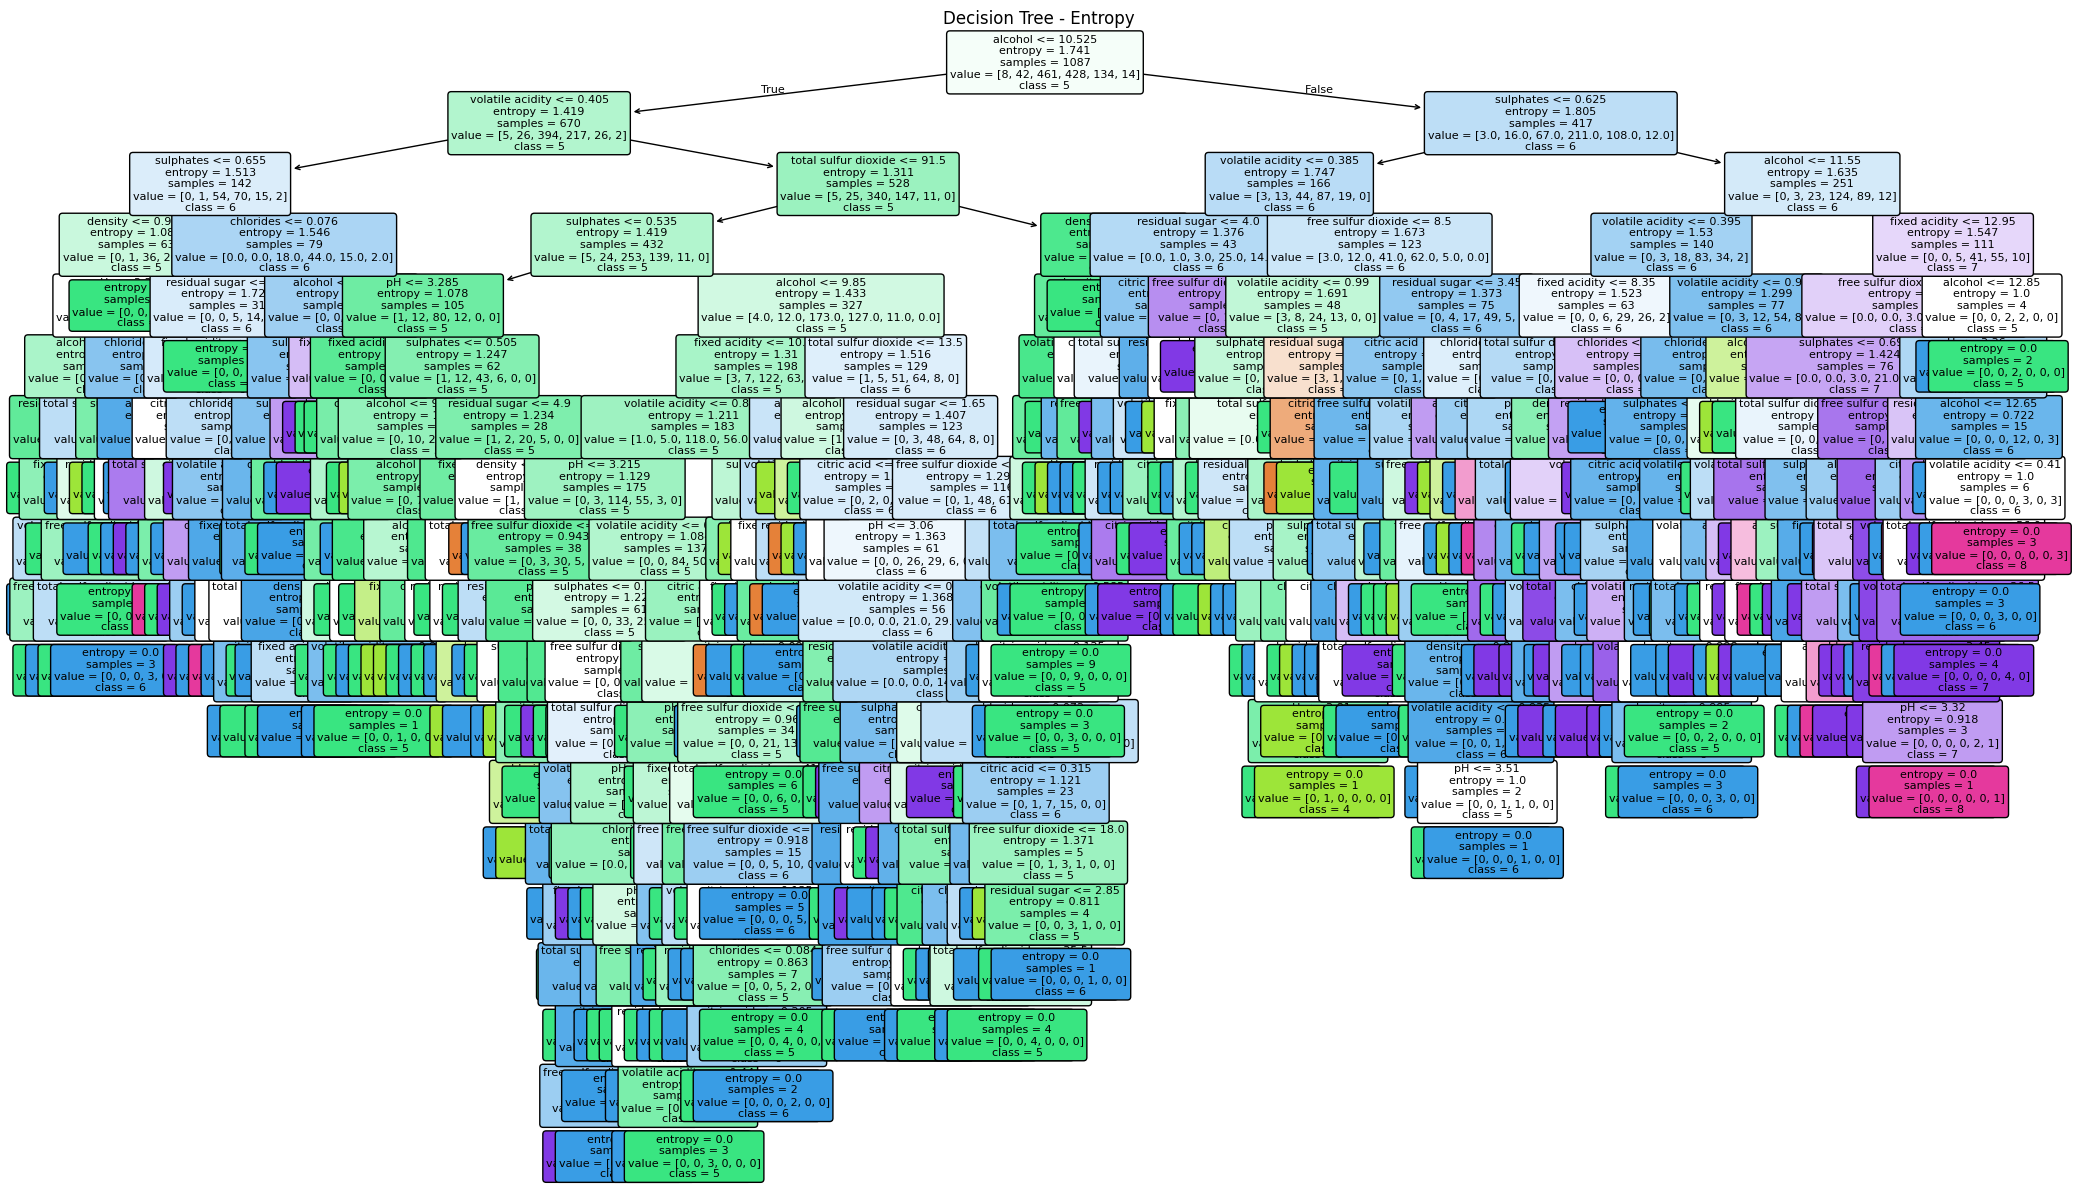

In [ ]:
plt.figure(figsize=(25,15))
plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree - Entropy")
plt.show()

# 7. ROC Curve and AUC

Evaluate classification performance using one-vs-rest ROC curves and Area Under the Curve (AUC).

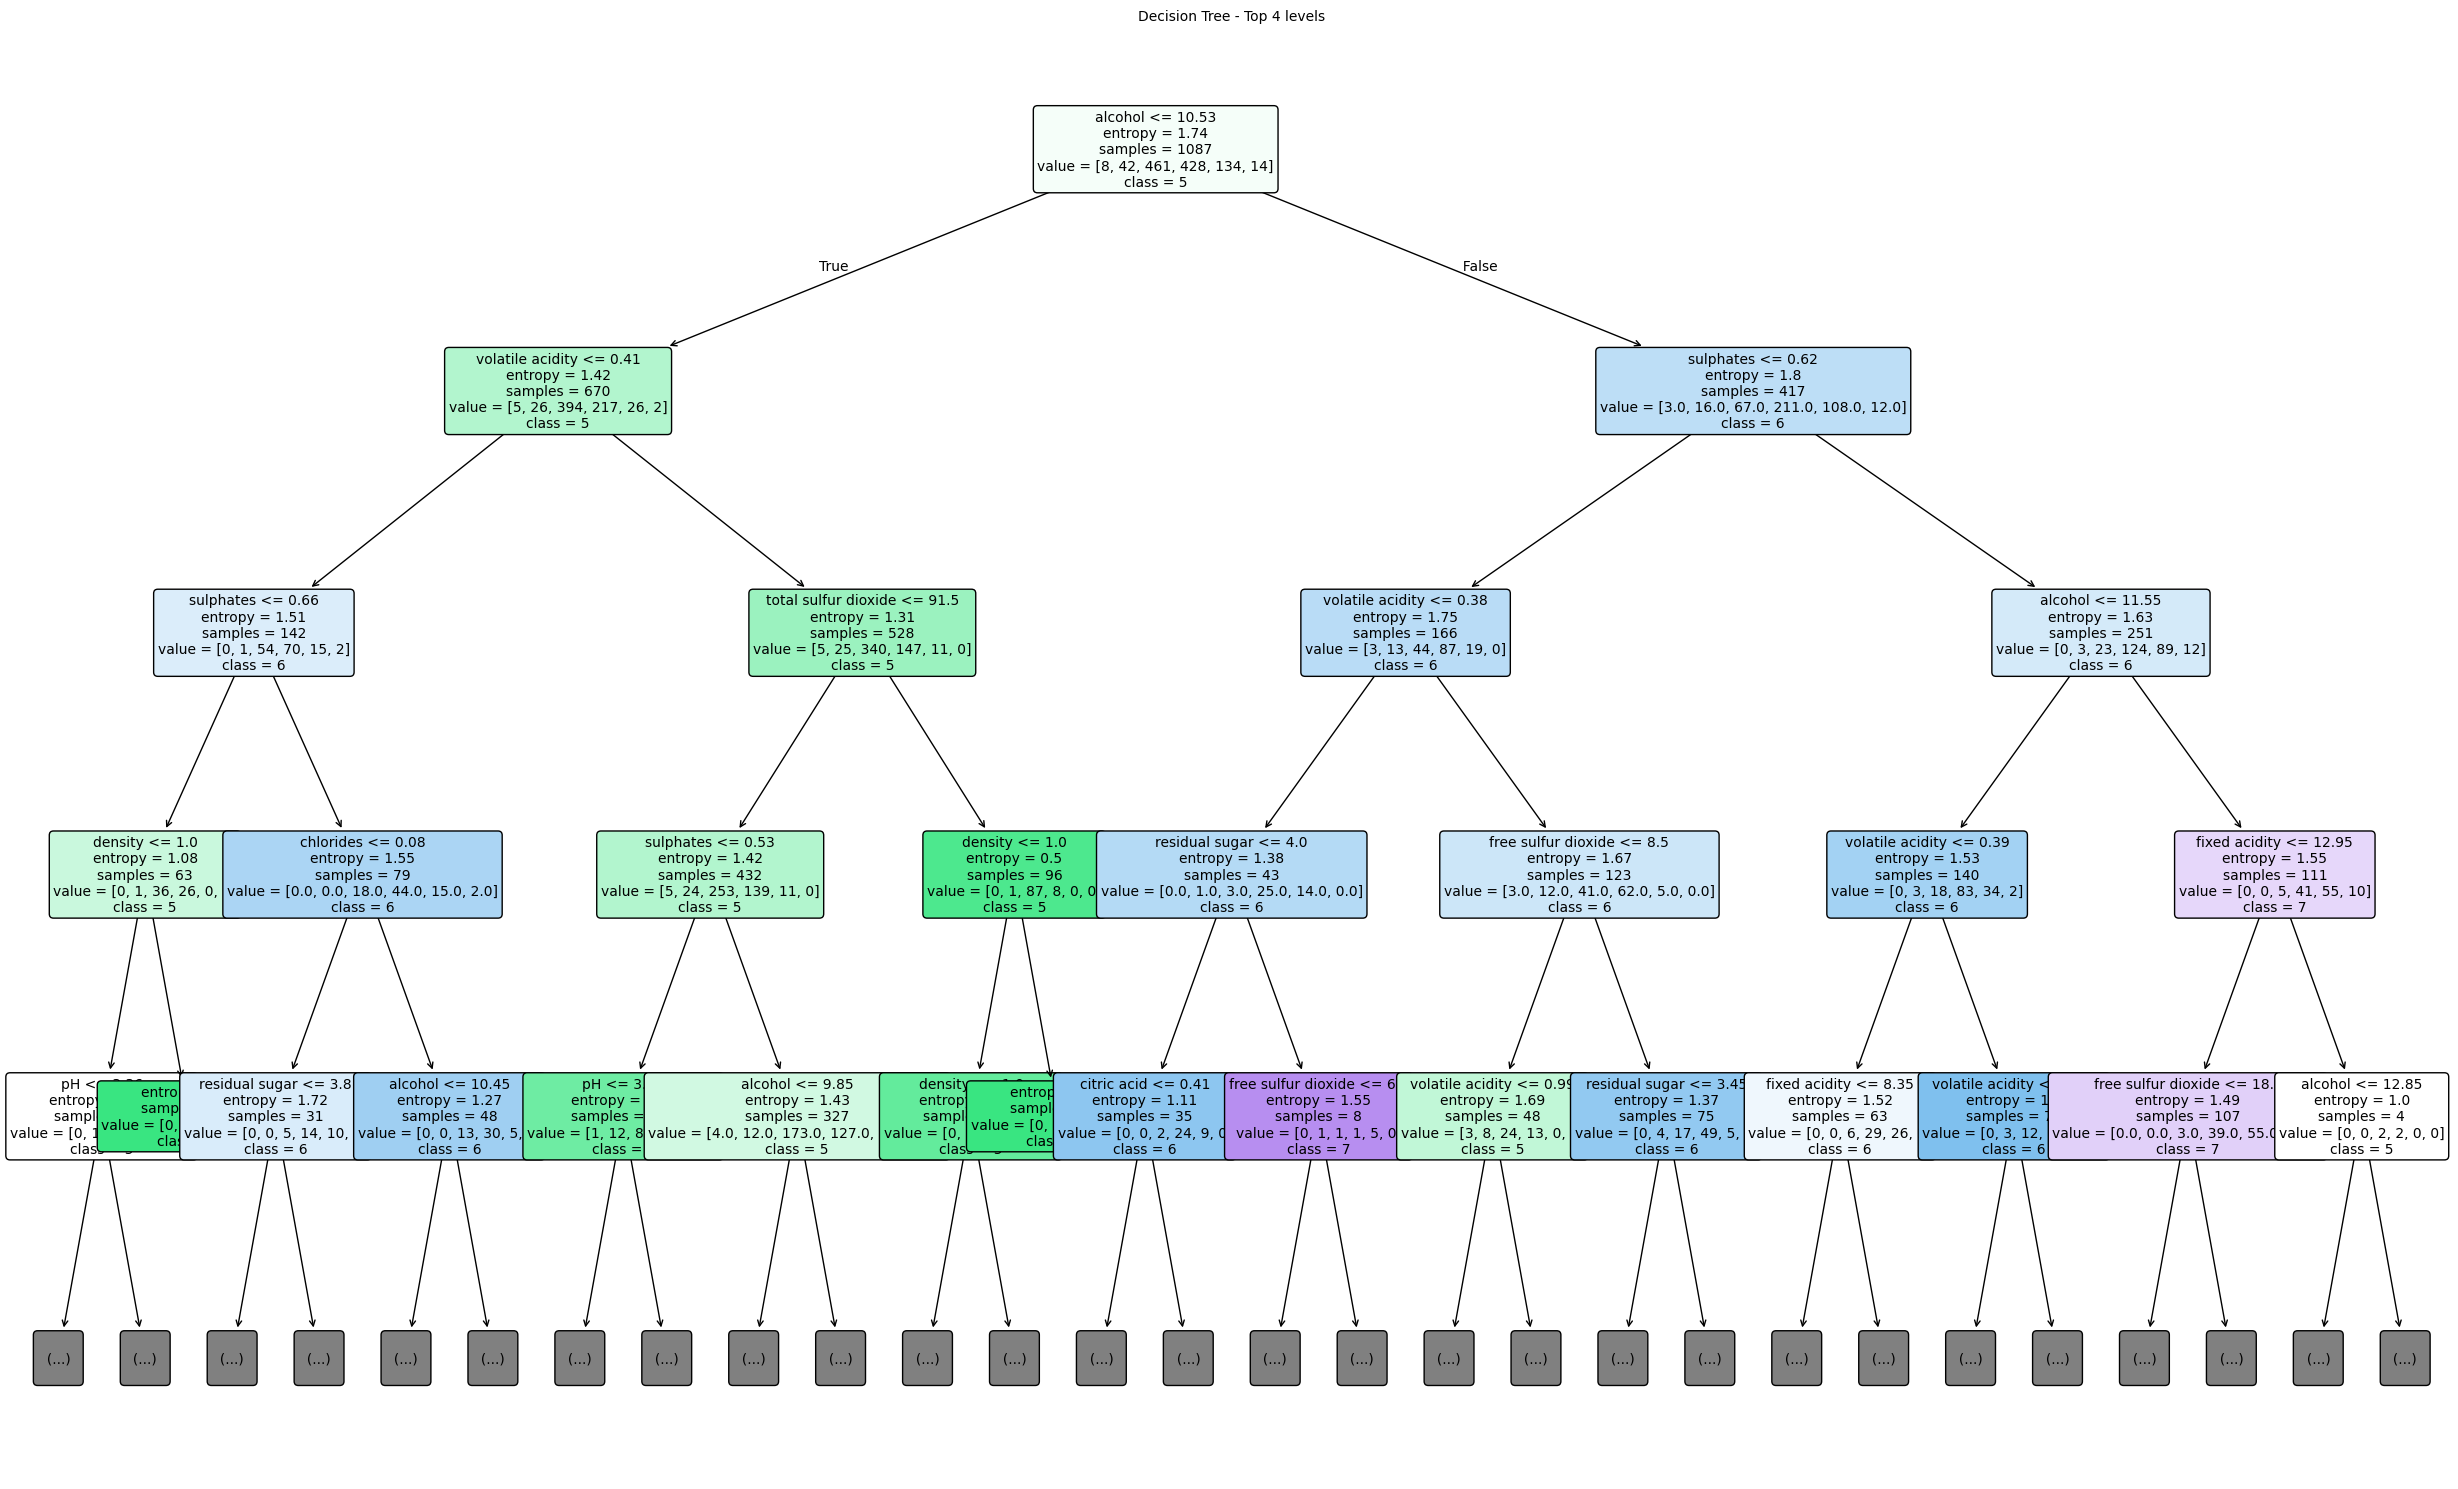

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))
plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2,
    fontsize=10,
    max_depth=4
)

plt.title("Decision Tree - Top 4 levels", fontsize=10)
plt.tight_layout()
plt.show()

### ROC Curve and AUC Before Hyperparameter Tuning

Calculate class-wise ROC curves and AUC values for the initial model.

# AUC ROC CURVE

# 8. Hyperparameter Tuning

Use GridSearchCV to search for a better combination of Decision Tree hyperparameters.

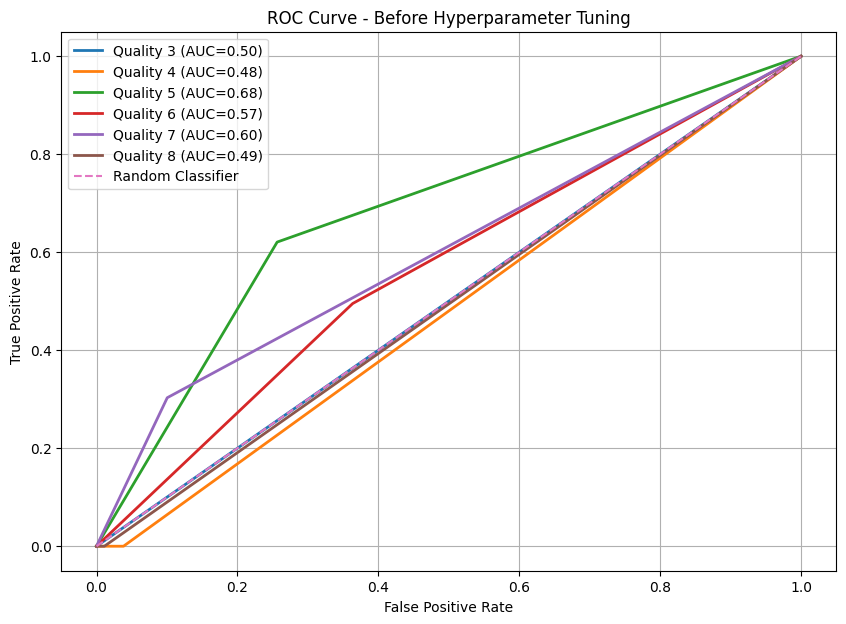

Overall ROC-AUC (Before Hyperparameter Tuning): 0.615


In [ ]:
# Search the parameter grid using cross-validated GridSearchCV.
#ROC CURVE AND AUC - BEFORE HYPERPARAMETER TUNING

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

#Get unique classes
classes=sorted(y_test.unique())

#Convert probability predictions
y_test_bin=label_binarize(y_test,classes=classes)

#Get probability predictions
y_score=dt_model.predict_proba(x_test)

#Plot ROC curve
plt.figure(figsize=(10,7))

for i,class_label in enumerate(classes):
    fpr,tpr, thresholds=roc_curve(y_test_bin[:,i],y_score[:,i])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,linewidth=2,label=f'Quality {class_label} (AUC={roc_auc:.2f})')

#Random classifier
plt.plot([0,1],[0,1],linestyle='--',label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Before Hyperparameter Tuning')
plt.legend()
plt.grid()
plt.show()

#Overall AUC
overall_auc_before=roc_auc_score(y_test_bin,y_score,multi_class='ovr',average='weighted')
print("Overall ROC-AUC (Before Hyperparameter Tuning):",round(overall_auc_before,4))



### Evaluate the Tuned Model

Generate predictions from the best estimator and review classification performance.

In [ ]:
# Evaluate predictions from the best hyperparameter configuration.
# @title Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid={
    'criterion':['entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,8],
    'max_features':[None,'sqrt','log2'],
    'ccp_alpha':[0,0.001,0.005,0.01]
}

grid=GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5,scoring='accuracy',n_jobs=1)

grid.fit(x_train,y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best Cross Validation Accuracy")
print(grid.best_score_)

best_tree=grid.best_estimator_

Best Parameters
{'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best Cross Validation Accuracy
0.5814399864710607


### Training vs. Test Accuracy After Tuning

Compare the tuned model's performance on training and unseen test data.

In [ ]:
# Compare training and testing accuracy after tuning.
y_pred=best_tree.predict(x_test)

print(classification_report(y_test,y_pred))
print("Accuracy =",accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.63      0.69      0.66       116
           6       0.53      0.54      0.54       107
           7       0.47      0.52      0.49        33
           8       0.00      0.00      0.00         3

    accuracy                           0.57       272
   macro avg       0.27      0.29      0.28       272
weighted avg       0.54      0.57      0.55       272

Accuracy = 0.5698529411764706


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Visualize the Tuned Decision Tree

Inspect the structure of the best tree found by GridSearchCV.

In [ ]:
#Training accuracy
train_accuracy=best_tree.score(x_train,y_train)

#Testing accuracy
test_accuracy=best_tree.score(x_test,y_test)

print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:",test_accuracy)

Training Accuracy: 0.6209751609935602
Testing Accuracy: 0.5698529411764706


# 9. Cross-Validation

Estimate how consistently the tuned model performs across different data splits.

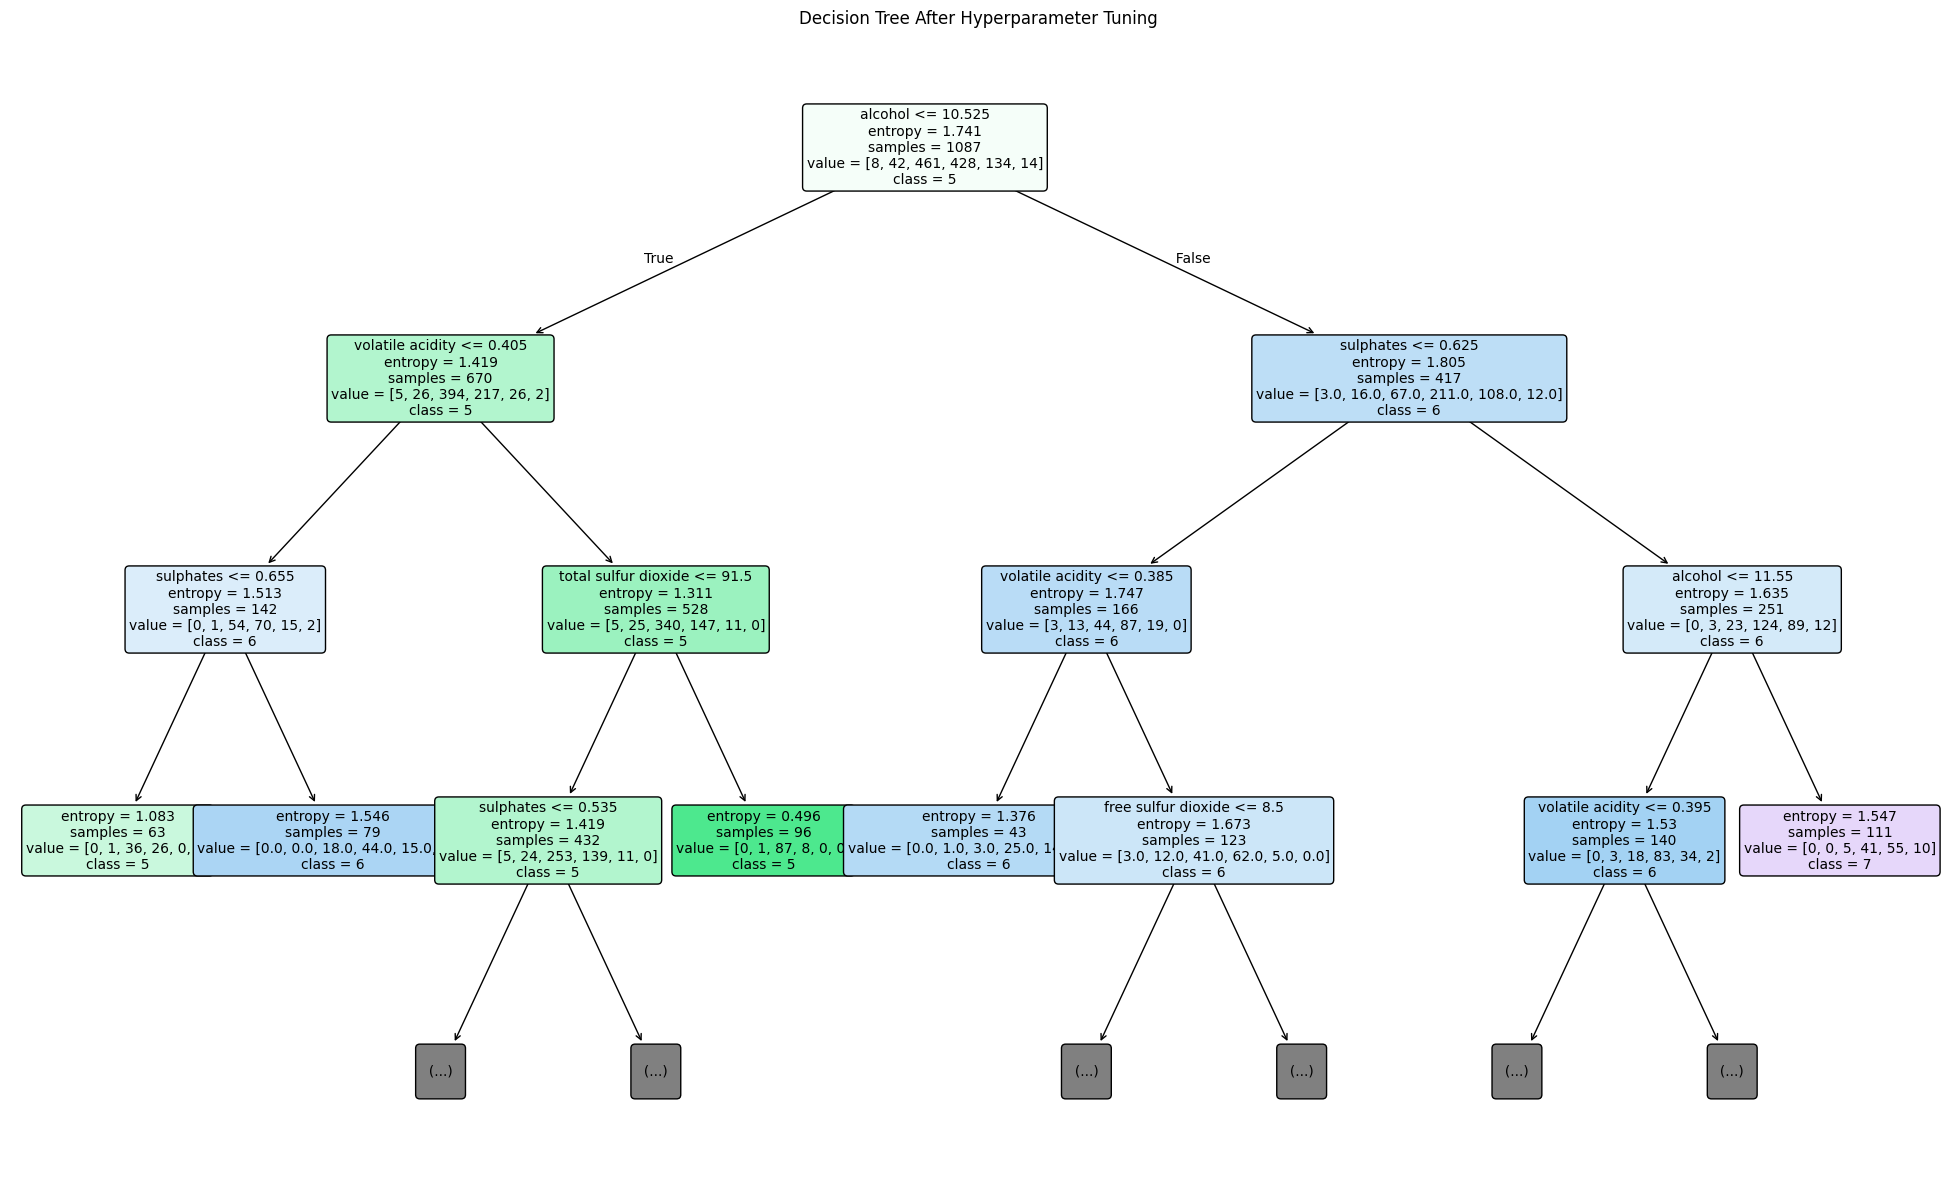

In [ ]:
# Estimate model stability using cross-validation scores.
plt.figure(figsize=(25,15))
plot_tree(
    best_tree,
    feature_names=x.columns,
    class_names=[str(c) for c in best_tree.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title("Decision Tree After Hyperparameter Tuning")
plt.show()

# 10. Learning Curve

Analyze training and validation performance as the amount of training data increases.

In [ ]:
# Generate training and validation scores for different training sizes.
# @title CROSS VALIDATION

from sklearn.model_selection import cross_val_score

scores=cross_val_score(best_tree,x,y,cv=10,scoring='accuracy')

print(scores)

print("Average Accuracy =",scores.mean())

print("Standard Deviation =",scores.std())


[0.46323529 0.60294118 0.61029412 0.5        0.58088235 0.59558824
 0.60294118 0.55147059 0.60294118 0.54814815]
Average Accuracy = 0.5658442265795207
Standard Deviation = 0.047538408739019426


# 11. Predict Quality for a New Wine

Create a sample wine observation and use the tuned model to predict its quality.

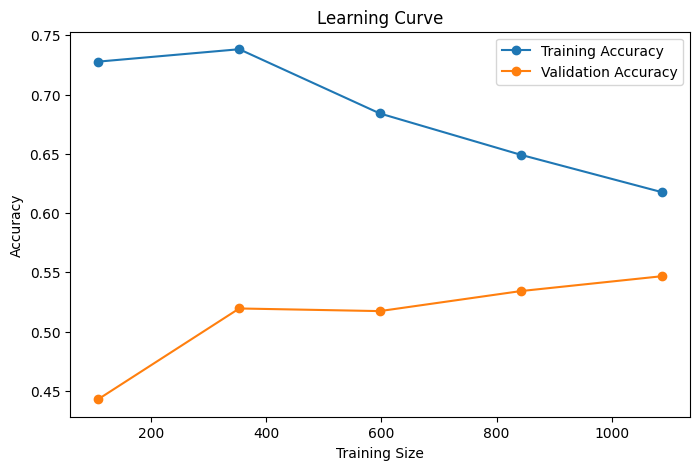

In [ ]:
# Define one new wine sample with the same feature structure as the training data.
# @title Learning Curve

from sklearn.model_selection import learning_curve

train_sizes,train_scores,test_scores=learning_curve(best_tree,x,y,cv=5,scoring='accuracy')

plt.figure(figsize=(8,5))

plt.plot(train_sizes,train_scores.mean(axis=1),marker='o',label='Training Accuracy')
plt.plot(train_sizes,test_scores.mean(axis=1),marker='o',label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")

plt.legend()
plt.show()

### Prediction and Class Probabilities

Predict the quality class and inspect probabilities across the classes.

In [ ]:
# Predict the quality class and obtain probabilities for all classes.
new_wine=pd.DataFrame([{
    'fixed acidity':7.4,
    'volatile acidity':0.7,
    'citric acid':0.0,
    'residual sugar':1.9,
    'chlorides':0.076,
    'free sulfur dioxide':11.0,
    'total sulfur dioxide':34.0,
    'density':0.9978,
    'pH':3.51,
    'sulphates':0.56,
    'alcohol':9.4
}])

prediction=best_tree.predict(new_wine)
print("Predicted Quality:",prediction[0])

Predicted Quality: 5


In [ ]:
probability=best_tree.predict_proba(new_wine)

print("Predicited Quality:",prediction[0])
print("Probabilities:",probability)

Predicited Quality: 5
Probabilities: [[0.01515152 0.03535354 0.61616162 0.31818182 0.01515152 0.        ]]
